
## Step 1: Load and Prepare the Dataset


### Enviroment SetUP

In [2]:
%pip install pandas numpy matplotlib  

Note: you may need to restart the kernel to use updated packages.


In [3]:
### Import required libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### 1.1 Load the dataset

In [140]:

df = pd.read_csv("data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [ ]:
### Binarize the target column: 1 = disease present, 0 = no disease

df["target"] = df["target"].apply(
    lambda v: 1 if v in (1, "yes", "Yes", "True", "present") else 0
).astype(int)

print(df["target"].value_counts())
print("dtype:", df["target"].dtype)

target
1    526
0    499
Name: count, dtype: int64
dtype: int64


In [ ]:
df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

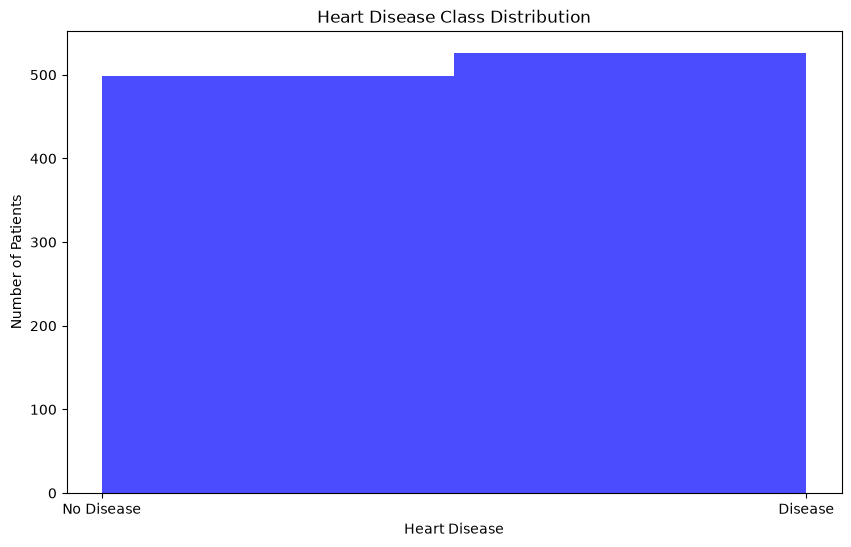

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df["target"], bins=2, color="blue", alpha=0.7)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Disease", "Disease"])
plt.show()

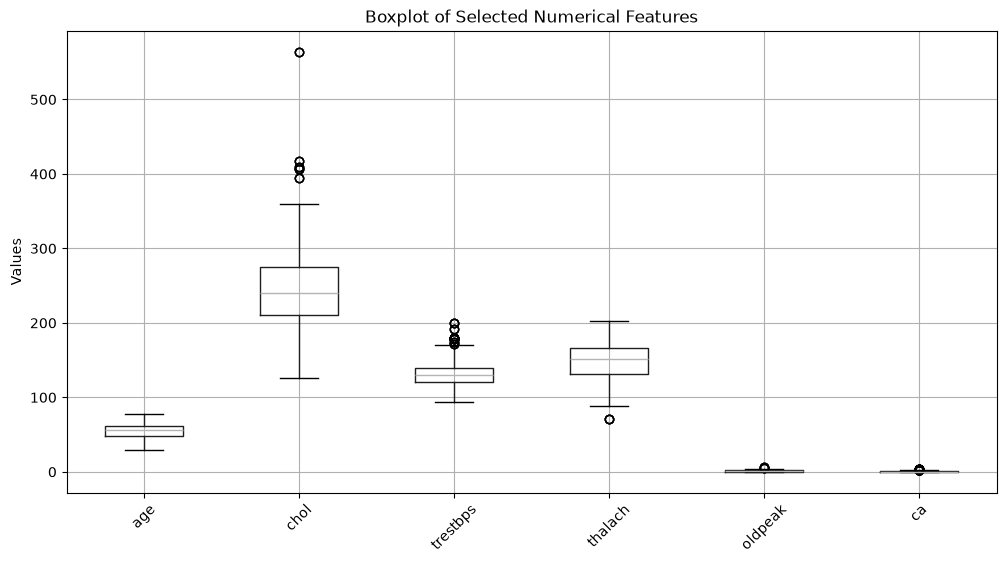

In [ ]:
features = ["age", "chol", "trestbps", "thalach", "oldpeak", "ca"]

plt.figure(figsize=(12, 6))

df[features].boxplot()

plt.title("Boxplot of Selected Numerical Features")
plt.ylabel("Values")
plt.xticks(rotation=45)

plt.show()


### 1.2 EDA summary and preprocessing decisions

- **Shape**: 1025 rows, 14 columns (13 features + the `target`).
- **Missing values**: none — `df.isnull().sum()` returns 0 for every column.
- **Class balance**: `target` has 526 patients with disease (51.3%) and 499 without (48.7%). The classes are well balanced, so no resampling is needed.
- **Outliers**: the boxplot shows extreme values in `chol` (max 564), `trestbps` (max 200), `oldpeak` (max 6.2) and `ca` (max 4). These are plausible physiological extremes for a small clinical sample, so no rows were removed; z-score scaling reduces their influence.
- **Preprocessing decisions**:
  - `target` binarized: 1 = disease present, 0 = absent.
  - 6 features selected: age, cholesterol, resting blood pressure, maximum heart rate, ST depression (`oldpeak`) and number of vessels (`ca`).
  - Stratified 70/30 train/test split to preserve the class ratio.
  - Numerical features normalized with z-scores computed from the **training set only**, to avoid data leakage into the test set.


In [ ]:
features = [
    "age",
    "chol",
    "trestbps",
    "thalach",
    "oldpeak",
    "ca"
]

X = df[features]
y = df["target"]

In [ ]:
np.random.seed(42)

indices_0 = df[df["target"] == 0].index.to_numpy().copy()
indices_1 = df[df["target"] == 1].index.to_numpy().copy()

np.random.shuffle(indices_0)
np.random.shuffle(indices_1)

split_0 = int(len(indices_0) * 0.70)
split_1 = int(len(indices_1) * 0.70)

train_indices = np.concatenate([
    indices_0[:split_0],
    indices_1[:split_1]
])

test_indices = np.concatenate([
    indices_0[split_0:],
    indices_1[split_1:]
])

X_train = df.loc[train_indices, features]
X_test = df.loc[test_indices, features]

y_train = df.loc[train_indices, "target"]
y_test = df.loc[test_indices, "target"]

In [ ]:
print("Training:", X_train.shape)
print("Test:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Training: (717, 6)
Test: (308, 6)

Training distribution:
target
1    368
0    349
Name: count, dtype: int64

Test distribution:
target
1    158
0    150
Name: count, dtype: int64


## Step 2: Basic Logistic Regression

In [ ]:
def sigmoid(z):
    """Compute the sigmoid of z."""
    return 1 / (1 + np.exp(-z))


In [ ]:
def compute_cost(w, b, X, y, lam=0):
    """Compute logistic regression cost J(w, b) with optional L2 regularization."""
    m, n = X.shape

    z = X @ w + b
    f = sigmoid(z)

    eps = 1e-8
    f_clipped = np.clip(f, eps, 1 - eps)

    J = -(1 / m) * np.sum(
        y * np.log(f_clipped) + (1 - y) * np.log(1 - f_clipped)
    )
    reg_term = (lam / (2 * m)) * np.sum(w ** 2)

    return J + reg_term

In [ ]:
def compute_gradient(w, b, X, y, lam=0):
    """Compute the gradient of the cost function with respect to w and b."""
    m, n = X.shape

    z = X @ w + b
    f = sigmoid(z)

    error = f - y

    dj_dw = (1 / m) * (X.T @ error) + (lam / m) * w
    dj_db = (1 / m) * np.sum(error)

    return dj_dw, dj_db

In [ ]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters, lam=0):
    """Perform gradient descent to learn w and b with optional L2 regularization."""
    w = w_in.copy()
    b = b_in
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(w, b, X, y, lam)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i % 100 == 0:
            J_history.append(compute_cost(w, b, X, y, lam))

    return w, b, J_history

In [ ]:
mean = X_train.mean()
std = X_train.std()

X_train_scaled = (X_train - mean) / std

In [ ]:
## Training the logistic regression model
w_initial = np.zeros(6)
b_initial = 0
alpha = 0.01
iterations = 1000
w, b, J_history = gradient_descent(X_train_scaled.to_numpy(), y_train.to_numpy(), w_initial, b_initial, alpha, iterations)

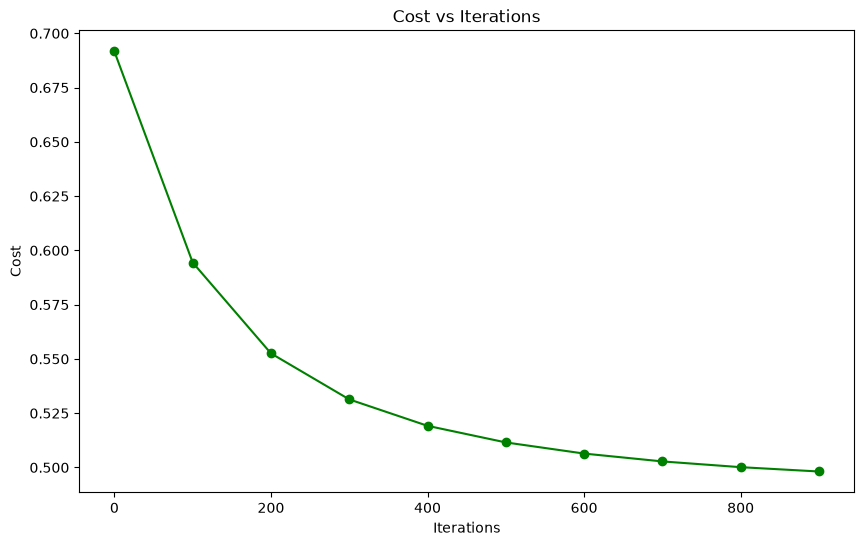

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(range(0, iterations, 100), J_history, marker='o', color='green')
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.show()


In [ ]:
def prediction(X, w, b):
    """Predict the class labels for input data X using learned parameters w and b."""
    z = X @ w + b
    f = sigmoid(z)
    return (f >= 0.5).astype(int)

In [ ]:
def accuracy(y_true, y_pred):
    """Compute the accuracy of predictions."""
    return np.mean(y_true == y_pred) * 100

In [ ]:
def precision(y_true, y_pred):
    """Compute the precision of predictions."""
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    predicted_positive = np.sum(y_pred == 1)
    return true_positive / predicted_positive if predicted_positive > 0 else 0

In [ ]:
def recall(y_true, y_pred):
    """Compute the recall of predictions."""
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    actual_positive = np.sum(y_true == 1)
    return true_positive / actual_positive if actual_positive > 0 else 0

In [ ]:
def F1_score(y_true, y_pred):
    """Compute the F1 score of predictions."""
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0

In [ ]:
y_pred_train = prediction(X_train_scaled.to_numpy(), w, b)
y_pred_test = prediction(((X_test - mean) / std).to_numpy(), w, b)
print("training set")
print(f"Accuracy: {accuracy(y_train.to_numpy(), y_pred_train):.2f}%")
print(f"Precision: {precision(y_train.to_numpy(), y_pred_train):.2f}")
print(f"Recall: {recall(y_train.to_numpy(), y_pred_train):.2f}")
print(f"F1 Score: {F1_score(y_train.to_numpy(), y_pred_train):.2f}")
print("\ntest set")
print(f"Accuracy: {accuracy(y_test.to_numpy(), y_pred_test):.2f}%")
print(f"Precision: {precision(y_test.to_numpy(), y_pred_test):.2f}")
print(f"Recall: {recall(y_test.to_numpy(), y_pred_test):.2f}")
print(f"F1 Score: {F1_score(y_test.to_numpy(), y_pred_test):.2f}")

training set
Accuracy: 73.92%
Precision: 0.73
Recall: 0.79
F1 Score: 0.76

test set
Accuracy: 75.32%
Precision: 0.74
Recall: 0.79
F1 Score: 0.77


In [ ]:
### Metrics table (train vs test)

y_pred_train = prediction(X_train_scaled.to_numpy(), w, b)
y_pred_test = prediction(((X_test - mean) / std).to_numpy(), w, b)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy (%)", "Precision", "Recall", "F1"],
    "Train": [
        accuracy(y_train.to_numpy(), y_pred_train),
        precision(y_train.to_numpy(), y_pred_train),
        recall(y_train.to_numpy(), y_pred_train),
        F1_score(y_train.to_numpy(), y_pred_train),
    ],
    "Test": [
        accuracy(y_test.to_numpy(), y_pred_test),
        precision(y_test.to_numpy(), y_pred_test),
        recall(y_test.to_numpy(), y_pred_test),
        F1_score(y_test.to_numpy(), y_pred_test),
    ],
})
metrics_df

,Metric,Train,Test
0,Accuracy (%),73.919107,75.324675
1,Precision,0.726817,0.744048
2,Recall,0.788043,0.791139
3,F1,0.756193,0.766871



### 2.2 Convergence and coefficient interpretation

**Convergence**: the cost fell from ≈0.692 at iteration 0 to ≈0.498 by iteration 900 and was still decreasing slowly. With α = 0.01 and 1,000 iterations the model is practically converged; the last 100 iterations only move the cost by <0.002, so more iterations would bring marginal gains.

**Coefficients** (all features are z-scored, so weights are directly comparable):

| Feature | w | exp(w) |
|---|---|---|
| age | −0.083 | 0.920 |
| chol | −0.158 | 0.854 |
| trestbps | −0.191 | 0.826 |
| thalach | +0.603 | 1.828 |
| oldpeak | −0.643 | 0.526 |
| ca | −0.606 | 0.545 |

`exp(w)` is the odds multiplier for a +1 standard-deviation increase in the feature. `thalach` (maximum heart rate) is the strongest positive predictor: each +1 std multiplies the odds of disease by ≈1.83. `oldpeak` (ST depression) and `ca` (number of vessels) are the strongest negative predictors, multiplying the odds by ≈0.53 and ≈0.55. Age, cholesterol and resting blood pressure contribute little in this model.


## Step 3: Decision Boundaries

In [ ]:

np.random.seed(42)
indices_2= df[df["target"] == 0].index.to_numpy().copy()
indices_3 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_2)
np.random.shuffle(indices_3)
split_2 = int(len(indices_2) * 0.70)
split_3 = int(len(indices_3) * 0.70)
train_indices = np.concatenate([
    indices_2[:split_2],
    indices_3[:split_3]
])
test_indices = np.concatenate([
    indices_2[split_2:],
    indices_3[split_3:]
])
X_train_pair_1 = df.loc[train_indices, ['age', 'chol']]
X_test_pair_1 = df.loc[test_indices, ['age', 'chol']]
y_train_pair_1 = df.loc[train_indices, "target"]
y_test_pair_1 = df.loc[test_indices, "target"]


In [ ]:
mean_pair = X_train_pair_1.mean()
std_pair = X_train_pair_1.std()
X_train_pair_scaled = (X_train_pair_1 - mean_pair) / std_pair
X_test_pair_scaled = (X_test_pair_1 - mean_pair) / std_pair

In [ ]:
w_initial_pair_1 = np.zeros(2)
b_initial_pair_1 = 0
alpha = 0.01
iterations = 1000
w_pair_1,b_pair_1,J_history_pair_1 = gradient_descent(X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(), w_initial_pair_1, b_initial_pair_1, alpha, iterations)

In [ ]:
def plot_linear_data_with_boundary(w, b, X, y, title, xlabel="x1", ylabel="x2"):
    plt.figure()
    plt.scatter(X[y == 0, 0], X[y == 0, 1], marker="o", label="y = 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], marker="x", label="y = 1")

    x1_vals = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 100)
    if abs(w[1]) > 1e-6:
        x2_vals = -(w[0] * x1_vals + b) / w[1]
        plt.plot(x1_vals, x2_vals, "k--", label="decision boundary")
    else:
        x1_line = -b / w[0]
        plt.axvline(x1_line, color="k", linestyle="--", label="decision boundary")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

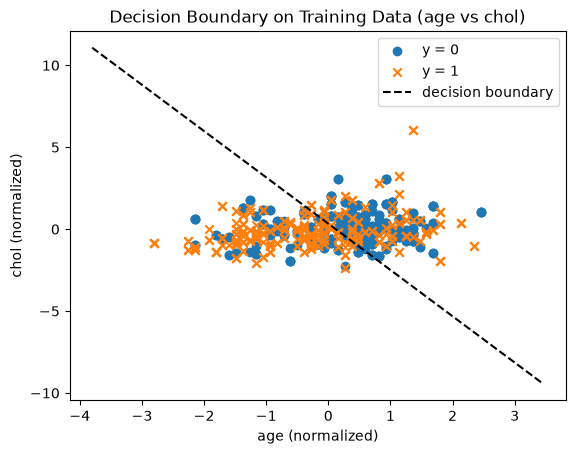

In [ ]:
plot_linear_data_with_boundary(
    w_pair_1, b_pair_1, X_train_pair_scaled.to_numpy(), y_train_pair_1.to_numpy(),
    "Decision Boundary on Training Data (age vs chol)",
    xlabel="age (normalized)", ylabel="chol (normalized)"
)

In [ ]:
np.random.seed(42)
indices_4= df[df["target"] == 0].index.to_numpy().copy()
indices_5 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_4)
np.random.shuffle(indices_5)
split_4 = int(len(indices_4) * 0.70)
split_5 = int(len(indices_5) * 0.70)
train_indices_2 = np.concatenate([
    indices_4[:split_4],
    indices_5[:split_5]
])
test_indices_2 = np.concatenate([
    indices_4[split_4:],
    indices_5[split_5:]
])
X_train_pair_4 = df.loc[train_indices_2, ['trestbps', 'thalach']]
X_test_pair_4 = df.loc[test_indices_2, ['trestbps', 'thalach']]
y_train_pair_4 = df.loc[train_indices_2, "target"]
y_test_pair_4 = df.loc[test_indices_2, "target"]


In [ ]:
mean_pair = X_train_pair_4.mean()
std_pair = X_train_pair_4.std()
X_train_pair_scaled_4 = (X_train_pair_4 - mean_pair) / std_pair
X_test_pair_scaled_4 = (X_test_pair_4 - mean_pair) / std_pair

In [ ]:
w_initial_pair_4 = np.zeros(2)
b_initial_pair_4 = 0
alpha = 0.01
iterations = 1000
w_pair_4,b_pair_4,J_history_pair_4 = gradient_descent(X_train_pair_scaled_4.to_numpy(), y_train_pair_4.to_numpy(), w_initial_pair_4, b_initial_pair_4, alpha, iterations)

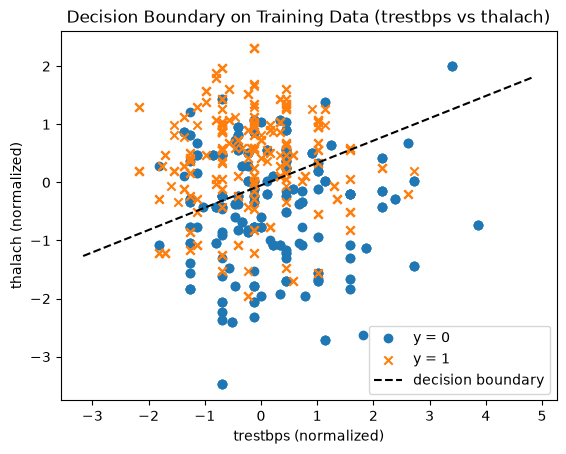

In [ ]:
plot_linear_data_with_boundary(
    w_pair_4, b_pair_4, X_train_pair_scaled_4.to_numpy(), y_train_pair_4.to_numpy(),
    "Decision Boundary on Training Data (trestbps vs thalach)",
    xlabel="trestbps (normalized)", ylabel="thalach (normalized)"
)

In [ ]:
np.random.seed(42)
indices_6= df[df["target"] == 0].index.to_numpy().copy()
indices_7 = df[df["target"] == 1].index.to_numpy().copy()
np.random.shuffle(indices_6)
np.random.shuffle(indices_7)
split_6 = int(len(indices_6) * 0.70)
split_7 = int(len(indices_7) * 0.70)
train_indices_3 = np.concatenate([
    indices_6[:split_6],
    indices_7[:split_7]
])
test_indices_3 = np.concatenate([
    indices_6[split_6:],
    indices_7[split_7:]
])
X_train_pair_5 = df.loc[train_indices_3, ['oldpeak', 'ca']]
X_test_pair_5 = df.loc[test_indices_3, ['oldpeak', 'ca']]
y_train_pair_5 = df.loc[train_indices_3, "target"]
y_test_pair_5 = df.loc[test_indices_3, "target"]


In [ ]:
mean_pair = X_train_pair_5.mean()
std_pair = X_train_pair_5.std()
X_train_pair_scaled_5 = (X_train_pair_5 - mean_pair) / std_pair
X_test_pair_scaled_5 = (X_test_pair_5 - mean_pair) / std_pair



In [ ]:
w_initial_pair = np.zeros(2)
b_initial_pair = 0
alpha = 0.01
iterations = 1000
w_pair_5,b_pair_5,J_history_pair_5 = gradient_descent(X_train_pair_scaled_5.to_numpy(), y_train_pair_5.to_numpy(), w_initial_pair, b_initial_pair, alpha, iterations)

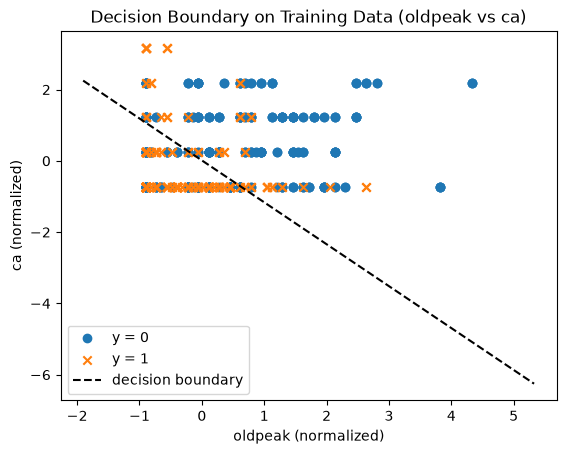

In [ ]:
plot_linear_data_with_boundary(
    w_pair_5, b_pair_5, X_train_pair_scaled_5.to_numpy(), y_train_pair_5.to_numpy(),
    "Decision Boundary on Training Data (oldpeak vs ca)",
    xlabel="oldpeak (normalized)", ylabel="ca (normalized)"
)


### 3.2 Interpretation of the decision boundaries

- **age vs chol**: the two classes overlap heavily (disease appears at all ages and cholesterol levels). The linear boundary separates the classes only weakly, confirming that these two features alone carry little discriminative power.
- **trestbps vs thalach**: `thalach` drives most of the separation — disease patients concentrate at high maximum heart rate — while `trestbps` contributes little. The boundary is nearly horizontal, and many points around the center are still misclassified.
- **oldpeak vs ca**: this pair shows the clearest visual separation of the three. Disease patients cluster at low `oldpeak` and low `ca`, and the boundary follows that trend. Some overlap remains, indicating a nonlinear decision surface would separate the classes even better.


## Step 4: Regularization


### 4.1 Tuning the regularization parameter λ


In [ ]:
lambda_values = [0, 0.001, 0.01, 0.1, 1]

X_test_scaled = (X_test - mean) / std

full_results = []
full_histories = {}

for lam in lambda_values:
    w_initial = np.zeros(X_train.shape[1])
    b_initial = 0

    w_reg, b_reg, J_history_reg = gradient_descent(
        X_train_scaled.to_numpy(),
        y_train.to_numpy(),
        w_initial,
        b_initial,
        alpha,
        iterations,
        lam
    )
    full_histories[lam] = J_history_reg

    y_pred_test = prediction(X_test_scaled.to_numpy(), w_reg, b_reg)

    full_results.append({
        "lambda": lam,
        "accuracy (%)": accuracy(y_test.to_numpy(), y_pred_test),
        "precision": precision(y_test.to_numpy(), y_pred_test),
        "recall": recall(y_test.to_numpy(), y_pred_test),
        "f1": F1_score(y_test.to_numpy(), y_pred_test),
        "||w||": np.linalg.norm(w_reg),
    })

results_df = pd.DataFrame(full_results)
results_df

,lambda,accuracy (%),precision,recall,f1,||w||
0,0.000,75.324675,0.744048,0.791139,0.766871,1.101545
1,0.001,75.324675,0.744048,0.791139,0.766871,1.101539
2,0.010,75.324675,0.744048,0.791139,0.766871,1.101489
3,0.100,75.324675,0.744048,0.791139,0.766871,1.100984
4,1.000,75.324675,0.744048,0.791139,0.766871,1.095965



### 4.2 Regularized cost curves (full model)


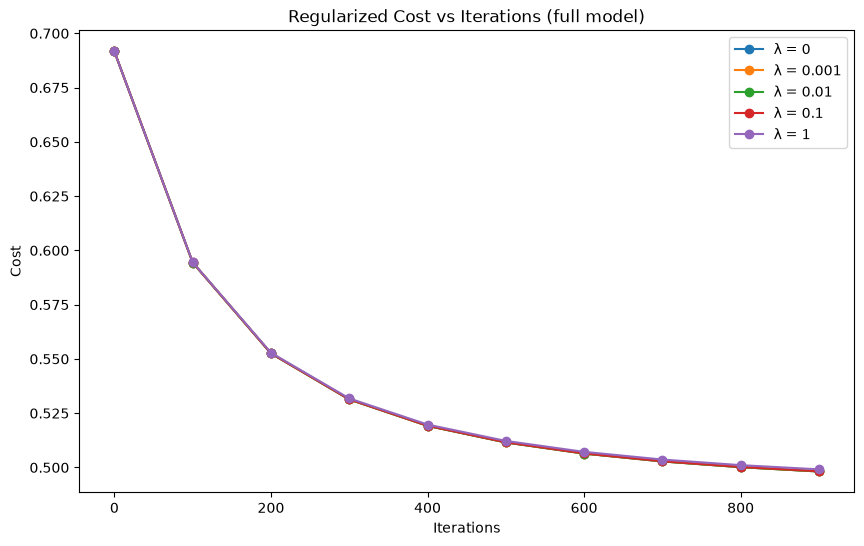

In [ ]:
plt.figure(figsize=(10, 6))
for lam, hist in full_histories.items():
    plt.plot(range(0, iterations, 100), hist, marker="o", label=f"λ = {lam}")
plt.title("Regularized Cost vs Iterations (full model)")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.show()


### 4.3 Regularized feature pairs

Each pair is retrained with every value of λ; the boundaries below use the selected λ.


In [ ]:
lam_sel = 0.1

pair_data = [
    ("age vs chol", X_train_pair_scaled, y_train_pair_1, "age", "chol"),
    ("trestbps vs thalach", X_train_pair_scaled_4, y_train_pair_4, "trestbps", "thalach"),
    ("oldpeak vs ca", X_train_pair_scaled_5, y_train_pair_5, "oldpeak", "ca"),
]

pair_results = {}
for name, Xp, yp, _, _ in pair_data:
    rows = []
    for lam in lambda_values:
        w_p, b_p, J_hist = gradient_descent(
            Xp.to_numpy(), yp.to_numpy(),
            np.zeros(Xp.shape[1]), 0.0, alpha, iterations, lam
        )
        rows.append({"lambda": lam, "w": w_p, "b": b_p, "w_norm": np.linalg.norm(w_p), "cost": J_hist[-1]})
    pair_results[name] = rows

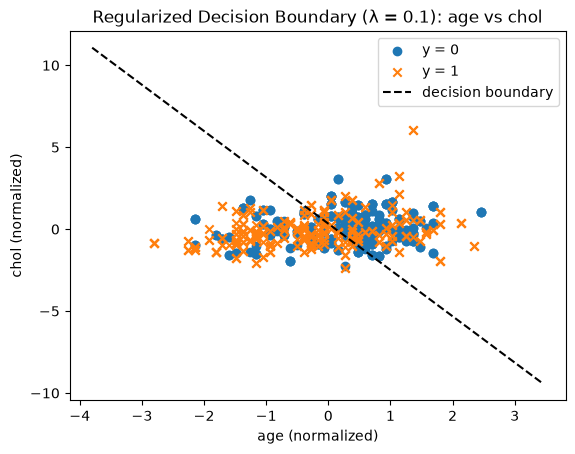

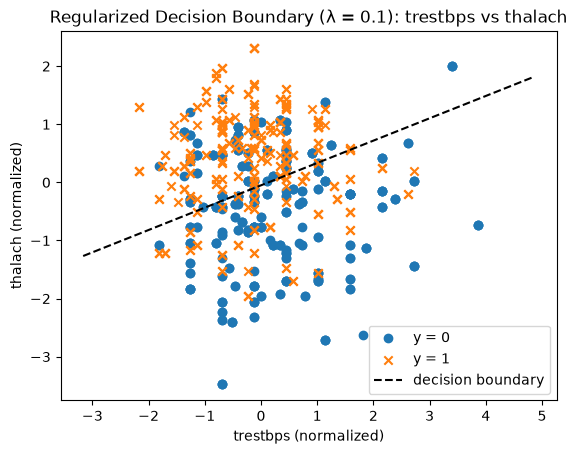

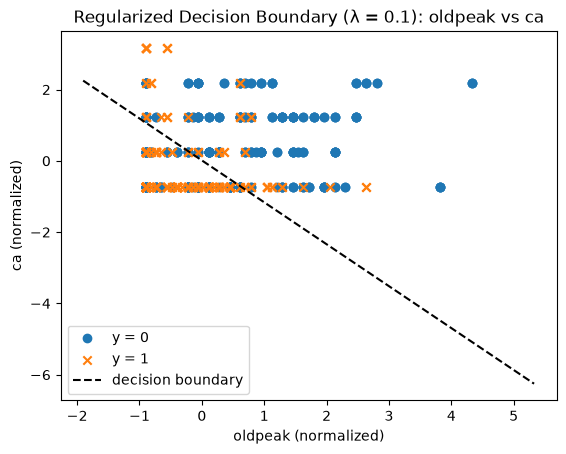

In [ ]:
for name, Xp, yp, xlab, ylab in pair_data:
    row = next(r for r in pair_results[name] if r["lambda"] == lam_sel)
    plot_linear_data_with_boundary(
        row["w"], row["b"], Xp.to_numpy(), yp.to_numpy(),
        f"Regularized Decision Boundary (λ = {lam_sel}): {name}",
        xlabel=f"{xlab} (normalized)", ylabel=f"{ylab} (normalized)",
    )


### 4.4 Unregularized vs regularized boundary (age vs chol)


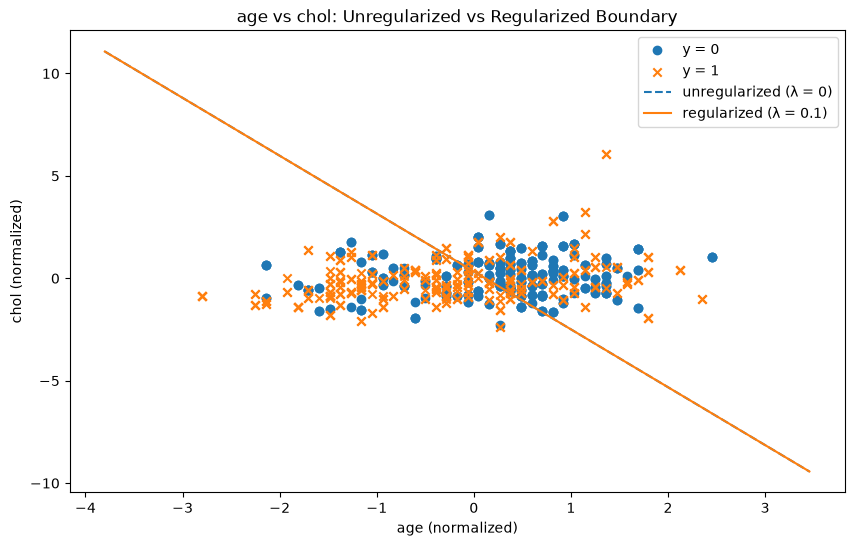

In [ ]:
rows_age_chol = pair_results["age vs chol"]
w_ur = rows_age_chol[0]["w"]
b_ur = rows_age_chol[0]["b"]
w_re = next(r for r in rows_age_chol if r["lambda"] == lam_sel)["w"]
b_re = next(r for r in rows_age_chol if r["lambda"] == lam_sel)["b"]

Xp = X_train_pair_scaled.to_numpy()
yp = y_train_pair_1.to_numpy()

plt.figure(figsize=(10, 6))
plt.scatter(Xp[yp == 0, 0], Xp[yp == 0, 1], marker="o", label="y = 0")
plt.scatter(Xp[yp == 1, 0], Xp[yp == 1, 1], marker="x", label="y = 1")

x1_vals = np.linspace(Xp[:, 0].min() - 1, Xp[:, 0].max() + 1, 100)
plt.plot(x1_vals, -(w_ur[0] * x1_vals + b_ur) / w_ur[1], "--", label="unregularized (λ = 0)")
plt.plot(x1_vals, -(w_re[0] * x1_vals + b_re) / w_re[1], "-", label=f"regularized (λ = {lam_sel})")
plt.title("age vs chol: Unregularized vs Regularized Boundary")
plt.xlabel("age (normalized)")
plt.ylabel("chol (normalized)")
plt.legend()
plt.show()


### 4.5 Choosing the regularization parameter

According to the results, all the values of λ produced the same test metrics: 75.32% accuracy, 0.74 precision, 0.79 recall, and 0.77 F1. The main difference was the weight norm, which decreased slightly as λ increased, from 1.1015 with λ = 0 to 1.0960 with λ = 1.

Since the training and test results are very similar, there does not seem to be a significant overfitting problem. For this reason, I chose λ = 0.1. It keeps the same performance while slightly reducing the weight values. In the age–cholesterol comparison, the decision boundary also changes only a little. This suggests that the regularization has a small effect on the model for these values of λ.



## Final Insights

The logistic regression model obtained about 75% accuracy on the test set, with an F1 score of 0.77. This is better than simply predicting the majority class, which would give around 51% accuracy.
Among the six features used, thalach, oldpeak, and ca had a stronger influence on the predictions, while age, chol, and trestbps had a smaller effect.
The models using only two features performed worse than the full model. This shows that using several features together gives the model more information to distinguish between the two classes.
The different regularization values produced almost exactly the same metrics. Because of this, I selected λ = 0.1, since it slightly reduces the weight norm without changing the model's performance.
Overall, the six-feature logistic regression model works reasonably well, but there is still room for improvement. Using feature interactions or a nonlinear model could help capture relationships that logistic regression cannot represent.